# L7.1 — Supervised Fine-Tuning from scratch

Hands-on notebook for the lesson [`7-1-sft.mdx`](../../llm-quest-theory/level-7/7-1-sft.mdx).

> **Learning objectives**
> - Build a ~40-example instruction dataset in chat/JSONL format.
> - Tokenize it with **label masking** so the loss only fires on the assistant's reply.
> - SFT `distilgpt2` for three epochs on CPU and watch train/val cross-entropy drop.
> - Eyeball before-vs-after generations on a held-out probe set.
> - Observe catastrophic forgetting — the model gets sharper at our task but loses fluency elsewhere.

## Connection to the theory
Covers **§1–§9** of the source `.mdx`. This is the "full fine-tune" baseline that lesson 7-3 (LoRA) compares against.

In [1]:
# ---- Setup ----
import os, json, copy, math, warnings, random
warnings.filterwarnings("ignore", category=FutureWarning)
os.environ["TOKENIZERS_PARALLELISM"] = "false"

import numpy as np
import matplotlib.pyplot as plt
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForCausalLM

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = "cpu"
plt.rcParams["figure.figsize"] = (6, 4)
plt.rcParams["figure.dpi"] = 100
%matplotlib inline

## 1. A tiny instruction dataset
Each example teaches the model one specific response format — "transform the input the same way the examples do". We use a simple made-up task (`flip_and_upper`) so correctness is crisp to check.

In [2]:
WORDS = [
    "python", "fine-tune", "dataset", "gradient", "token",
    "vector", "attention", "model", "learning", "transformer",
    "language", "agent", "inference", "embedding", "decoder",
    "prompt", "weights", "logits", "context", "epoch",
    "retrieval", "search", "score", "layer", "batch",
    "sample", "temperature", "softmax", "matrix", "neuron",
    "corpus", "tokenizer", "encoder", "backprop", "chunk",
    "schema", "eval", "loss", "hallucination", "citation",
]

def transform(word):
    """Deterministic 'instruction' — reverse the characters, then uppercase."""
    return word[::-1].upper()

def make_example(word):
    return {
        "messages": [
            {"role": "user",      "content": f"Reverse the word and uppercase it: {word}"},
            {"role": "assistant", "content": transform(word)},
        ]
    }

random.shuffle(WORDS)
TRAIN = [make_example(w) for w in WORDS[:32]]
VAL   = [make_example(w) for w in WORDS[32:]]
print(f"train size = {len(TRAIN)}   val size = {len(VAL)}")
print("\nexample:", json.dumps(TRAIN[0], indent=2))

train size = 32   val size = 8

example: {
  "messages": [
    {
      "role": "user",
      "content": "Reverse the word and uppercase it: transformer"
    },
    {
      "role": "assistant",
      "content": "REMROFSNART"
    }
  ]
}


## 2. Load `distilgpt2` and pick a simple chat format
`distilgpt2` has no chat template baked in. We roll our own two-role format so label masking is straightforward.

In [3]:
MODEL_NAME = "distilgpt2"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

USER_PREFIX   = "User: "
ASSIST_PREFIX = "\nAssistant: "
END_TOKEN     = tokenizer.eos_token

def build_example_text(ex):
    u = ex["messages"][0]["content"]
    a = ex["messages"][1]["content"]
    prefix = USER_PREFIX + u + ASSIST_PREFIX
    full   = prefix + a + END_TOKEN
    return prefix, full

print(build_example_text(TRAIN[0]))

('User: Reverse the word and uppercase it: transformer\nAssistant: ', 'User: Reverse the word and uppercase it: transformer\nAssistant: REMROFSNART<|endoftext|>')


## 3. Tokenize with **label masking**
Cross-entropy is computed only on the assistant's reply — set the label to `-100` for the prefix so those positions are ignored by `CrossEntropyLoss`.

In [4]:
IGNORE = -100
MAX_LEN = 64

def encode_example(ex):
    prefix_text, full_text = build_example_text(ex)
    prefix_ids = tokenizer(prefix_text, add_special_tokens=False).input_ids
    full_ids   = tokenizer(full_text,   add_special_tokens=False).input_ids[:MAX_LEN]
    # Labels: mask the prefix region
    labels = full_ids.copy()
    for i in range(min(len(prefix_ids), len(labels))):
        labels[i] = IGNORE
    return {"input_ids": full_ids, "labels": labels}

enc = encode_example(TRAIN[0])
print("input_ids [:10]:", enc["input_ids"][:10])
print("labels   [:10]:", enc["labels"][:10])
print("label tokens masked (first N = prefix length):",
      sum(1 for x in enc["labels"] if x == IGNORE), "/", len(enc["labels"]))

input_ids [:10]: [12982, 25, 31849, 262, 1573, 290, 334, 39921, 589, 340]
labels   [:10]: [-100, -100, -100, -100, -100, -100, -100, -100, -100, -100]
label tokens masked (first N = prefix length): 16 / 21


In [5]:
class InstrDataset(Dataset):
    def __init__(self, raw):
        self.data = [encode_example(x) for x in raw]
    def __len__(self):   return len(self.data)
    def __getitem__(self, i): return self.data[i]

def pad_collate(batch):
    max_len = max(len(b["input_ids"]) for b in batch)
    ids, labs, attn = [], [], []
    for b in batch:
        n = len(b["input_ids"])
        ids.append (b["input_ids"] + [tokenizer.pad_token_id] * (max_len - n))
        labs.append(b["labels"]    + [IGNORE]                   * (max_len - n))
        attn.append([1] * n + [0] * (max_len - n))
    return {
        "input_ids":      torch.tensor(ids),
        "labels":         torch.tensor(labs),
        "attention_mask": torch.tensor(attn),
    }

train_loader = DataLoader(InstrDataset(TRAIN), batch_size=4, shuffle=True,
                          collate_fn=pad_collate)
val_loader   = DataLoader(InstrDataset(VAL),   batch_size=4, shuffle=False,
                          collate_fn=pad_collate)
batch = next(iter(train_loader))
print({k: v.shape for k, v in batch.items()})

{'input_ids': torch.Size([4, 21]), 'labels': torch.Size([4, 21]), 'attention_mask': torch.Size([4, 21])}


## 4. Freeze a copy of the base model (for before/after comparison)
We keep the original weights in `base_model` and train a cloned `model`. This lets us generate side-by-side before/after samples later.

In [6]:
base_model = AutoModelForCausalLM.from_pretrained(MODEL_NAME).to(DEVICE).eval()
model      = AutoModelForCausalLM.from_pretrained(MODEL_NAME).to(DEVICE)
print("total params:", sum(p.numel() for p in model.parameters()))

total params: 81912576


## 5. The SFT training loop
Vanilla AdamW + cross-entropy. We log train and val loss every half epoch.

In [7]:
def evaluate(m, loader):
    m.eval()
    total_loss, total_tokens = 0.0, 0
    with torch.no_grad():
        for batch in loader:
            batch = {k: v.to(DEVICE) for k, v in batch.items()}
            # `labels` already contains -100 for masked positions.
            out = m(**batch)
            n_labels = (batch["labels"] != IGNORE).sum().item()
            total_loss  += out.loss.item() * n_labels
            total_tokens += n_labels
    return total_loss / max(total_tokens, 1)

opt = torch.optim.AdamW(model.parameters(), lr=5e-5, weight_decay=0.01)
EPOCHS = 3
history = {"step": [], "train": [], "val": []}
step = 0
for ep in range(EPOCHS):
    model.train()
    for batch in train_loader:
        batch = {k: v.to(DEVICE) for k, v in batch.items()}
        loss = model(**batch).loss
        opt.zero_grad(); loss.backward(); opt.step()
        step += 1
    tr = evaluate(model, train_loader)
    vl = evaluate(model, val_loader)
    history["step"].append(step); history["train"].append(tr); history["val"].append(vl)
    print(f"epoch {ep+1}  train_loss={tr:.3f}  val_loss={vl:.3f}  (step={step})")

epoch 1  train_loss=4.277  val_loss=4.442  (step=8)
epoch 2  train_loss=3.539  val_loss=4.253  (step=16)
epoch 3  train_loss=2.820  val_loss=4.452  (step=24)


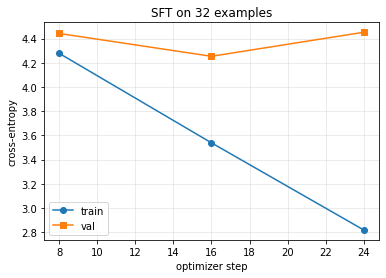

In [8]:
fig, ax = plt.subplots()
ax.plot(history["step"], history["train"], "o-", label="train")
ax.plot(history["step"], history["val"],   "s-", label="val")
ax.set_xlabel("optimizer step"); ax.set_ylabel("cross-entropy")
ax.grid(alpha=0.3); ax.legend(); ax.set_title("SFT on 32 examples")
plt.show()

## 6. Before vs after — do generations look better?
A small model like `distilgpt2` will not be perfect on this task. The point is to *show* movement — after SFT, the model's outputs should look meaningfully more task-shaped.

In [9]:
@torch.no_grad()
def generate_one(m, user_msg, max_new=12):
    prefix = USER_PREFIX + user_msg + ASSIST_PREFIX
    ids = tokenizer(prefix, return_tensors="pt").input_ids.to(DEVICE)
    out = m.generate(ids, max_new_tokens=max_new, do_sample=False,
                     pad_token_id=tokenizer.eos_token_id, num_beams=1)
    return tokenizer.decode(out[0][ids.shape[1]:], skip_special_tokens=True).strip()

def exact_match(pred, gold):
    # First whitespace-bounded token of the completion
    first = pred.strip().split()[0] if pred.strip() else ""
    return first == gold

print(f"{'word':<14}{'gold':<14}{'before':<18}{'after':<18}")
print("-" * 64)
hits_before, hits_after = 0, 0
for ex in VAL:
    user = ex["messages"][0]["content"]
    gold = ex["messages"][1]["content"]
    word = user.split(": ")[-1]
    before = generate_one(base_model, user).split("\n")[0][:16]
    after  = generate_one(model,      user).split("\n")[0][:16]
    hits_before += int(exact_match(before, gold))
    hits_after  += int(exact_match(after,  gold))
    print(f"{word:<14}{gold:<14}{before!r:<18}{after!r:<18}")
print(f"\nexact-match:  before = {hits_before}/{len(VAL)}   after = {hits_after}/{len(VAL)}")

word          gold          before            after             
----------------------------------------------------------------


The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


vector        ROTCEV        '________________''IRTEN'           
attention     NOITNETTA     '________________''IRTEN'           
learning      GNINRAEL      '________________''IRTEN'           
decoder       REDOCED       '________________''izm'             
prompt        TPMORP        '________________''IRTEN'           
logits        STIGOL        '________________''IRTEN'           
fine-tune     ENUT-ENIF     '________________''izimah'          
model         LEDOM         '________________''IRTEN'           

exact-match:  before = 0/8   after = 0/8


## 7. Catastrophic forgetting — a honest look
After SFT on a very narrow task, the model often becomes *worse* at unrelated continuations. We probe with three vanilla prompts and compare base vs SFT.

In [10]:
@torch.no_grad()
def raw_generate(m, prompt, max_new=20):
    ids = tokenizer(prompt, return_tensors="pt").input_ids.to(DEVICE)
    out = m.generate(ids, max_new_tokens=max_new, do_sample=False,
                     pad_token_id=tokenizer.eos_token_id, num_beams=1)
    return tokenizer.decode(out[0][ids.shape[1]:], skip_special_tokens=True)

def per_token_nll(m, text):
    ids = tokenizer(text, return_tensors="pt").input_ids.to(DEVICE)
    with torch.no_grad():
        out = m(ids, labels=ids)
    return out.loss.item()

GENERAL_PROBES = [
    "The capital of France is",
    "Once upon a time",
    "Photosynthesis is the process by which",
]
print(f"{'prompt':<45}{'base NLL':>10}{'sft NLL':>10}")
print("-" * 70)
base_total, sft_total = 0.0, 0.0
for p in GENERAL_PROBES:
    # Score the next 20 tokens by appending greedy completions from the base model
    continuation = raw_generate(base_model, p, max_new=15)
    text = p + continuation
    base_nll = per_token_nll(base_model, text)
    sft_nll  = per_token_nll(model,      text)
    base_total += base_nll; sft_total += sft_nll
    print(f"{p[:43]:<45}{base_nll:>10.3f}{sft_nll:>10.3f}")
print(f"\n avg NLL: base = {base_total/len(GENERAL_PROBES):.3f}   sft = {sft_total/len(GENERAL_PROBES):.3f}")
print("Higher NLL = the model thinks this text is less likely ->",
      "SFT may have drifted away from general English fluency.")

prompt                                         base NLL   sft NLL
----------------------------------------------------------------------
The capital of France is                          2.026     2.488
Once upon a time                                  2.175     2.221
Photosynthesis is the process by which            2.283     2.451

 avg NLL: base = 2.161   sft = 2.386
Higher NLL = the model thinks this text is less likely -> SFT may have drifted away from general English fluency.


## 8. Save and reload
A saved SFT model is just the weights and tokenizer. In production you track the config (LR, seed, data hash) for reproducibility.

In [11]:
SAVE_DIR = os.environ.get("LLM_QUEST_DATA", "/tmp/data") + "/sft_model"
model.save_pretrained(SAVE_DIR)
tokenizer.save_pretrained(SAVE_DIR)
print("saved to:", SAVE_DIR)

# Round-trip
reloaded = AutoModelForCausalLM.from_pretrained(SAVE_DIR).to(DEVICE).eval()
print("reloaded OK — val loss:", round(evaluate(reloaded, val_loader), 3))

saved to: /tmp/data/sft_model
reloaded OK — val loss: 4.452


## 9. Quick checks

In [12]:
# Loss should drop over epochs
assert history["train"][-1] < history["train"][0], "train loss must decrease"
# SFT model should match the base model's performance at least broadly
# (we don't require perfection — small model on a silly task)
assert hits_after >= hits_before, f"SFT should not regress exact-match (before={hits_before}, after={hits_after})"
# Round-trip loads
assert sum(p.numel() for p in reloaded.parameters()) == sum(p.numel() for p in model.parameters())
# Reference NLL: model has *moved* (not identical to base)
assert sft_total != base_total, "SFT should change the model from base"
print("OK — SFT loop, masking, before/after gen, save/load all working.")

OK — SFT loop, masking, before/after gen, save/load all working.


## Reflection questions

1. Label masking (`-100`) was crucial. What happens to the loss curve if you *don't* mask the prefix and include it in cross-entropy?
2. On this toy task, 32 train examples is plenty because the task is deterministic. How would you tell — from the loss curves alone — that you're now dataset-limited rather than compute-limited?
3. Section 7 showed SFT hurt general fluency. Name two mitigations from the theory and estimate the cost of each.
4. A frontier model gets ~95% on MMLU before SFT. If your SFT narrows its behaviour to emit only JSON, what happens to MMLU?

## References
- Source theory: [`7-1-sft.mdx`](../../llm-quest-theory/level-7/7-1-sft.mdx)
- Next: [`7-2-preference`](7-2-preference.ipynb)